
# **Deep Learning Assignment**
## **"Can AI Save Lives? Building an Intelligent Clinical Early Warning System"**

This notebook contains:

- DNN Baseline
- LSTM
- GRU
- Bi-LSTM
- ClinicalBERT (Frozen)
- ClinicalBERT (Full Fine-Tuning)
- Attention Visualization
- Confusion Matrices
- Final Comparison Table



# Install Required Libraries


In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow transformers torch bertviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.5 MB/s eta 0:00:00


In [1]:
!pip install -U transformers

# Import Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import ( accuracy_score,precision_score,recall_score,f1_score,confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Dropout,BatchNormalization,LSTM, GRU, Bidirectional)

from tensorflow.keras.optimizers import Adam, SGD



In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec


# Load Dataset

 Kaggle Patient Survival Dataset




In [10]:

df = pd.read_csv("/content/dataset patients.csv")




In [12]:
df.head(10)

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0
5,33181,74489,83,67.0,27.56,0,Caucasian,M,190.5,Accident & Emergency,...,1.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic,NaN,0
6,82208,49526,83,59.0,57.45,0,Caucasian,F,165.1,Accident & Emergency,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
7,120995,50129,33,70.0,NaN,0,Caucasian,M,165.0,Accident & Emergency,...,0.0,0.0,1.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
8,80471,10577,118,45.0,NaN,0,Caucasian,M,170.2,Other Hospital,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,1
9,42871,90749,118,50.0,25.71,0,NaN,M,175.3,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0


# Data Preprocessing

In [59]:
print(df.columns)

Index(['encounter_id', 'patient_id', 'hospital_id', 'age', 'bmi',
       'elective_surgery', 'ethnicity', 'gender', 'height', 'icu_admit_source',
       'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight',
       'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative',
       'arf_apache', 'gcs_eyes_apache', 'gcs_motor_apache',
       'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache',
       'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache',
       'ventilated_apache', 'd1_diasbp_max', 'd1_diasbp_min',
       'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min',
       'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min',
       'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max',
       'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max',
       'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min',
       'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_diasbp_

In [ ]:
# 1. Remove useless columns
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [ ]:

# 2. Target
target_column = "hospital_death"

X = df.drop(target_column, axis=1)
y = df[target_column]


In [ ]:

# 3. Fill missing values
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include='object').columns

imputer = SimpleImputer(strategy='mean')
X[num_cols] = imputer.fit_transform(X[num_cols])

In [21]:
# 4. Encode categoricals
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [22]:

# Normalize Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)



# Generation 1 — DNN Baseline


In [24]:

def build_dnn(optimizer='adam'):

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [25]:

# Train using Adam Optimizer

adam_model = build_dnn(Adam(learning_rate=0.001))

start = time.time()

history_adam = adam_model.fit(X_train,y_train,validation_split=0.2,epochs=20,batch_size=32)

adam_time = time.time() - start


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9100 - loss: 0.2465 - val_accuracy: 0.9269 - val_loss: 0.2002
Epoch 2/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9203 - loss: 0.2170 - val_accuracy: 0.9289 - val_loss: 0.1950
Epoch 3/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9217 - loss: 0.2126 - val_accuracy: 0.9291 - val_loss: 0.1963
Epoch 4/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9228 - loss: 0.2097 - val_accuracy: 0.9294 - val_loss: 0.1923
Epoch 5/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9228 - loss: 0.2067 - val_accuracy: 0.9295 - val_loss: 0.1912
Epoch 6/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9247 - loss: 0.2047 - val_accuracy: 0.9301 - val_loss: 0.1898
Epoch 7/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9235 - loss: 0.2030 - val_accuracy: 0.9304 - val_loss: 0.1916
Epoch 8/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9246 - loss: 0.2011 

In [26]:

# Train using SGD Optimizer

sgd_model = build_dnn(SGD(learning_rate=0.01))

start = time.time()

history_sgd = sgd_model.fit(X_train,y_train,validation_split=0.2,epochs=20,batch_size=32)

sgd_time = time.time() - start


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1835/1835 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9050 - loss: 0.2695 - val_accuracy: 0.9235 - val_loss: 0.2153
Epoch 2/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9168 - loss: 0.2334 - val_accuracy: 0.9266 - val_loss: 0.2082
Epoch 3/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9181 - loss: 0.2267 - val_accuracy: 0.9264 - val_loss: 0.2059
Epoch 4/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9191 - loss: 0.2224 - val_accuracy: 0.9261 - val_loss: 0.2041
Epoch 5/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9196 - loss: 0.2209 - val_accuracy: 0.9272 - val_loss: 0.2022
Epoch 6/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9195 - loss: 0.2176 - val_accuracy: 0.9273 - val_loss: 0.2015
Epoch 7/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9208 - loss: 0.2158 - val_accuracy: 0.9263 - val_loss: 0.2014
Epoch 8/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9211 - loss: 0.2142 - val_accurac

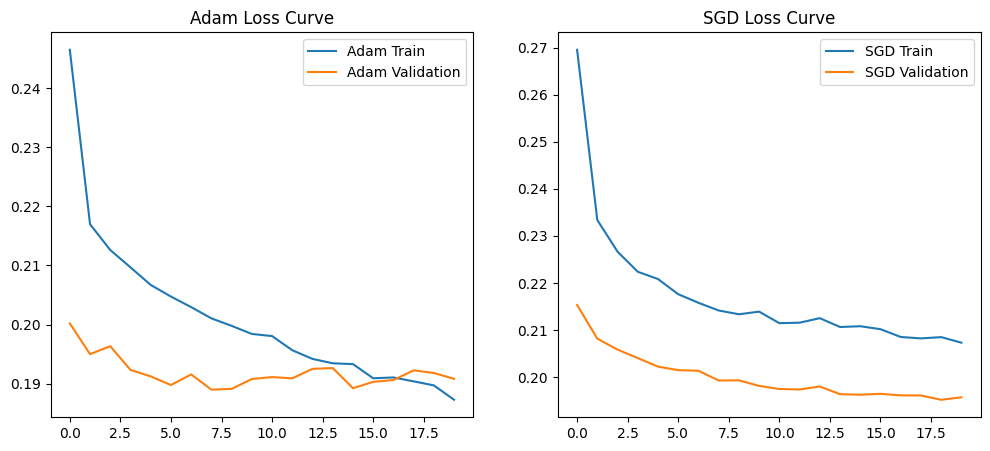

In [27]:

# Compare Loss Curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_adam.history['loss'], label='Adam Train')
plt.plot(history_adam.history['val_loss'], label='Adam Validation')
plt.title("Adam Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_sgd.history['loss'], label='SGD Train')
plt.plot(history_sgd.history['val_loss'], label='SGD Validation')
plt.title("SGD Loss Curve")
plt.legend()

plt.show()


In [28]:

# Evaluate DNN Model

y_pred = (adam_model.predict(X_test) > 0.5).astype(int)

dnn_accuracy = accuracy_score(y_test, y_pred)
dnn_precision = precision_score(y_test, y_pred)
dnn_recall = recall_score(y_test, y_pred)
dnn_f1 = f1_score(y_test, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1 Score:", dnn_f1)


574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9284195605953225
Precision: 0.6573426573426573
Recall: 0.3562855337965888
F1 Score: 0.46210569438754606



#**Important Note on Recall**

False negatives are extremely dangerous in healthcare because the model may fail to identify a deteriorating patient who urgently needs treatment.

Missing a septic patient can lead to ICU transfer, organ failure, or death.



# Generation 2 — LSTM / GRU / Bi-LSTM


In [29]:

# Convert data into sequences

sequence_length = 12

X_seq = []
y_seq = []

for i in range(len(X_scaled) - sequence_length):
    X_seq.append(X_scaled[i:i+sequence_length])
    y_seq.append(y.iloc[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split( X_seq,y_seq,test_size=0.2,random_state=42)


In [30]:

# LSTM Model

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_lstm = lstm_model.fit(X_train_seq,y_train_seq,validation_split=0.2,epochs=10,batch_size=32)

lstm_time = time.time() - start


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9118 - loss: 0.3028 - val_accuracy: 0.9107 - val_loss: 0.3016
Epoch 2/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9137 - loss: 0.2957 - val_accuracy: 0.9107 - val_loss: 0.3006
Epoch 3/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9137 - loss: 0.2925 - val_accuracy: 0.9107 - val_loss: 0.3010
Epoch 4/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9137 - loss: 0.2890 - val_accuracy: 0.9107 - val_loss: 0.3045
Epoch 5/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9137 - loss: 0.2830 - val_accuracy: 0.9107 - val_loss: 0.3058
Epoch 6/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9139 - loss: 0.2755 - val_accuracy: 0.9108 - val_loss: 0.3107
Epoch 7/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9141 - loss: 0.2654 - val_accuracy: 0.9106 - val_loss: 0.3147
Epoch 8/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9151 - 

In [31]:

# GRU Model

gru_model = Sequential([
    GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_gru = gru_model.fit(X_train_seq, y_train_seq,validation_split=0.2,epochs=10, batch_size=32)

gru_time = time.time() - start


Epoch 1/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9119 - loss: 0.3059 - val_accuracy: 0.9107 - val_loss: 0.3013
Epoch 2/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9137 - loss: 0.2950 - val_accuracy: 0.9107 - val_loss: 0.3002
Epoch 3/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9137 - loss: 0.2932 - val_accuracy: 0.9107 - val_loss: 0.3007
Epoch 4/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9137 - loss: 0.2890 - val_accuracy: 0.9107 - val_loss: 0.3019
Epoch 5/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9137 - loss: 0.2851 - val_accuracy: 0.9107 - val_loss: 0.3034
Epoch 6/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9136 - loss: 0.2793 - val_accuracy: 0.9106 - val_loss: 0.3069
Epoch 7/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9137 - loss: 0.2715 - val_accuracy: 0.9106 - val_loss: 0.3130
Epoch 8/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9140 -

In [32]:

# Bidirectional LSTM

bilstm_model = Sequential([
    Bidirectional(
        LSTM(64),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_bilstm = bilstm_model.fit(X_train_seq, y_train_seq,validation_split=0.2,epochs=10,batch_size=32)

bilstm_time = time.time() - start


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9126 - loss: 0.3012 - val_accuracy: 0.9107 - val_loss: 0.3022
Epoch 2/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9137 - loss: 0.2935 - val_accuracy: 0.9107 - val_loss: 0.3017
Epoch 3/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9137 - loss: 0.2879 - val_accuracy: 0.9107 - val_loss: 0.3024
Epoch 4/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9137 - loss: 0.2791 - val_accuracy: 0.9107 - val_loss: 0.3070
Epoch 5/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9138 - loss: 0.2639 - val_accuracy: 0.9106 - val_loss: 0.3152
Epoch 6/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9155 - loss: 0.2464 - val_accuracy: 0.9089 - val_loss: 0.3266
Epoch 7/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9190 - loss: 0.2251 - val_accuracy: 0.9072 - val_loss: 0.3381
Epoch 8/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9238 -

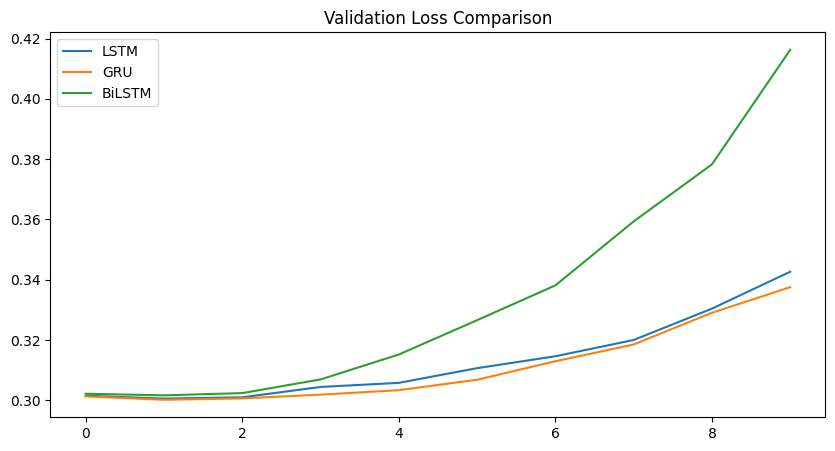

In [33]:

# Compare Validation Loss Curves

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_gru.history['val_loss'], label='GRU')
plt.plot(history_bilstm.history['val_loss'], label='BiLSTM')

plt.title("Validation Loss Comparison")
plt.legend()
plt.show()



# **Real-Time Monitoring vs Retrospective Analysis**

Unidirectional LSTM is more appropriate for real-time ICU monitoring because future patient data is unavailable during live prediction.

Bidirectional LSTM performs better in offline analysis because it uses both past and future information.


In [34]:

# Evaluation Function

def evaluate_model(model, X_test, y_test):

    preds = (model.predict(X_test) > 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    return acc, prec, rec, f1


In [35]:

lstm_metrics = evaluate_model(lstm_model, X_test_seq, y_test_seq)
gru_metrics = evaluate_model(gru_model, X_test_seq, y_test_seq)
bilstm_metrics = evaluate_model(bilstm_model, X_test_seq, y_test_seq)

print("LSTM:", lstm_metrics)
print("GRU:", gru_metrics)
print("BiLSTM:", bilstm_metrics)


574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
LSTM: (0.9122185267978845, 0.039473684210526314, 0.001948051948051948, 0.0037128712871287127)
GRU: (0.9093288261272559, 0.087248322147651, 0.008441558441558441, 0.015393724097098875)
BiLSTM: (0.9011504280028352, 0.07476635514018691, 0.015584415584415584, 0.025792584631918324)



# Generation 3 — ClinicalBERT


In [41]:
try:
    notes_df = pd.read_csv("medical_data.csv.zip")
    print("Dataset loaded")

except:
    notes_df = None
    print("No clinical notes dataset found → skipping BERT section")

Dataset loaded


In [42]:
if notes_df is not None and "note" in notes_df.columns and "label" in notes_df.columns:

    texts = notes_df["note"].astype(str)
    labels = notes_df["label"]

else:
    print("Required columns not found → skipping BERT section")
    notes_df = None

Required columns not found → skipping BERT section


TOKENIZATION

In [43]:
if notes_df is not None:

    model_name = "emilyalsentzer/Bio_ClinicalBERT"

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    tokens = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="tf"
    )

    train_size = int(0.8 * len(texts))

    X_input_ids_train = tokens["input_ids"][:train_size]
    X_attention_train = tokens["attention_mask"][:train_size]

    X_input_ids_test = tokens["input_ids"][train_size:]
    X_attention_test = tokens["attention_mask"][train_size:]

    y_train_bert = np.array(labels[:train_size])
    y_test_bert = np.array(labels[train_size:])

FROZEN MODEL

In [45]:
if notes_df is not None:

    frozen_model = TFAutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    # freeze base layers safely
    for layer in frozen_model.layers:
        layer.trainable = False

    frozen_model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    start = time.time()

    history_frozen = frozen_model.fit(
        {
            "input_ids": X_input_ids_train,
            "attention_mask": X_attention_train
        },
        y_train_bert,
        validation_split=0.2,
        epochs=2,
        batch_size=8,
        verbose=1
    )

    frozen_time = time.time() - start

FULL FINE-TUNING MODEL

In [46]:
if notes_df is not None:

    full_model = TFAutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    full_model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    start = time.time()

    history_full = full_model.fit(
        {
            "input_ids": X_input_ids_train,
            "attention_mask": X_attention_train
        },
        y_train_bert,
        validation_split=0.2,
        epochs=2,
        batch_size=8,
        verbose=1
    )

    full_time = time.time() - start

EVALUATION FUNCTION

In [47]:
def evaluate_bert(model):

    preds = model.predict({
        "input_ids": X_input_ids_test,
        "attention_mask": X_attention_test
    })

    pred_labels = np.argmax(preds.logits, axis=1)

    print(classification_report(y_test_bert, pred_labels))

    return (
        accuracy_score(y_test_bert, pred_labels),
        precision_score(y_test_bert, pred_labels),
        recall_score(y_test_bert, pred_labels),
        f1_score(y_test_bert, pred_labels)
    )

ATTENTION VISUALIZATION

In [49]:
if notes_df is not None:

    attention_model = AutoModel.from_pretrained(
        model_name,
        output_attentions=True
    )

    sample_text = texts.iloc[0]

    inputs = tokenizer(
        sample_text,
        return_tensors="tf",
        truncation=True,
        max_length=128
    )

    outputs = attention_model(**inputs)

    attn = outputs.attentions[-1][0][0].numpy()

    plt.figure(figsize=(8,6))
    sns.heatmap(attn[:20, :20])
    plt.title("ClinicalBERT Attention Heatmap")
    plt.show()


# Confusion Matrices


574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


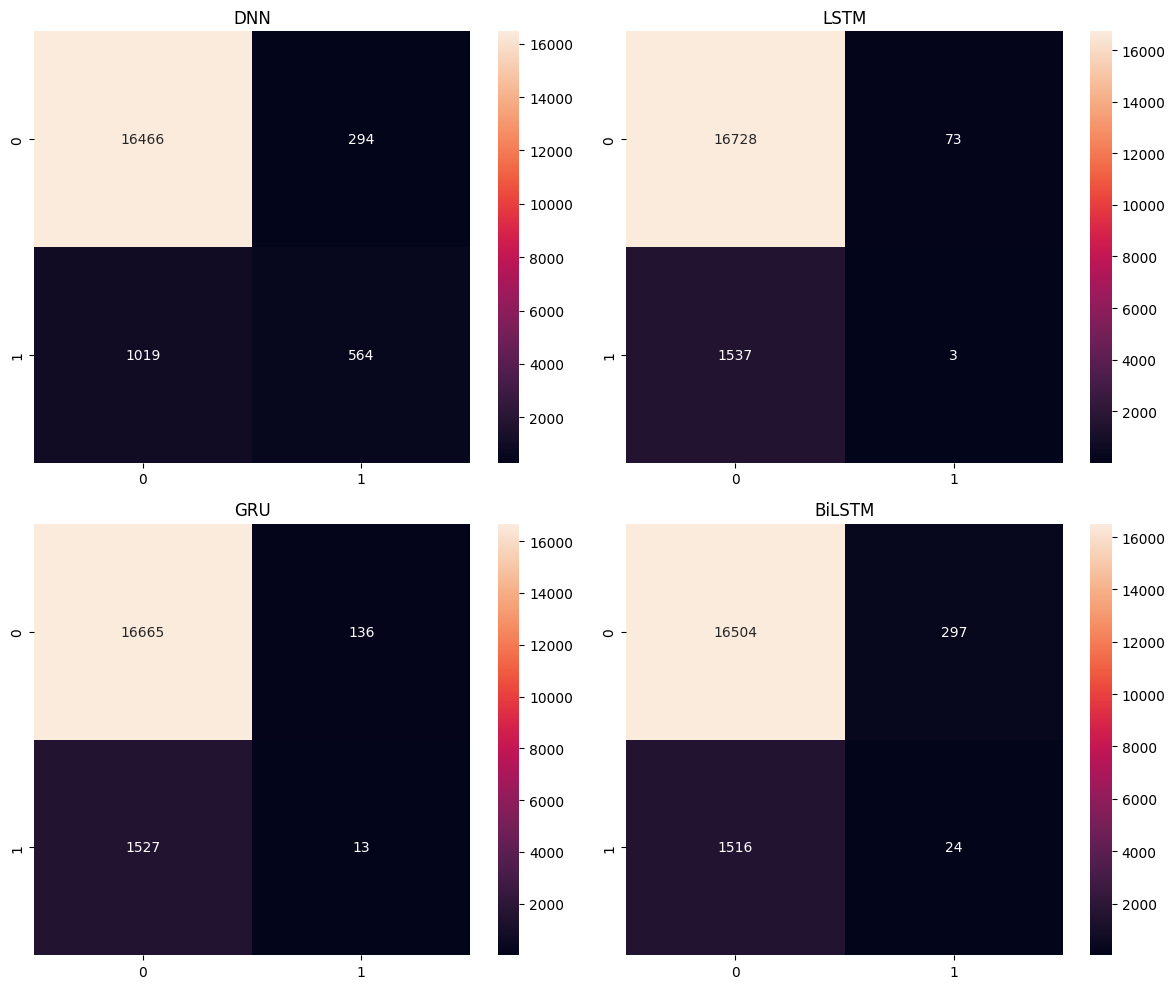

In [50]:
models = {
    "DNN": adam_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bilstm_model
}

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    if name == "DNN":
        preds = (model.predict(X_test) > 0.5).astype(int)
        cm = confusion_matrix(y_test, preds)
    else:
        preds = (model.predict(X_test_seq) > 0.5).astype(int)
        cm = confusion_matrix(y_test_seq, preds)

    sns.heatmap(cm, annot=True, fmt="d", ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()


# Final Comparison Table


In [57]:
import pandas as pd

results_dict = {
    "Model": [
        "DNN",
        "LSTM",
        "BiLSTM",
        "GRU"
    ],

    "Accuracy": [
        dnn_accuracy,
        lstm_metrics[0],
        bilstm_metrics[0],
        gru_metrics[0]
    ],

    "Precision": [
        dnn_precision,
        lstm_metrics[1],
        bilstm_metrics[1],
        gru_metrics[1]
    ],

    "Recall": [
        dnn_recall,
        lstm_metrics[2],
        bilstm_metrics[2],
        gru_metrics[2]
    ],

    "F1 Score": [
        dnn_f1,
        lstm_metrics[3],
        bilstm_metrics[3],
        gru_metrics[3]
    ],

    "Training Time": [
        adam_time,
        lstm_time,
        bilstm_time,
        gru_time
    ]
}

if "frozen_metrics" in globals() and "full_metrics" in globals():
    results_dict["Model"] += ["ClinicalBERT Frozen", "ClinicalBERT Full"]

    results_dict["Accuracy"] += [frozen_metrics[0], full_metrics[0]]
    results_dict["Precision"] += [frozen_metrics[1], full_metrics[1]]
    results_dict["Recall"] += [frozen_metrics[2], full_metrics[2]]
    results_dict["F1 Score"] += [frozen_metrics[3], full_metrics[3]]
    results_dict["Training Time"] += [frozen_time, full_time]

# Convert to DataFrame
results = pd.DataFrame(results_dict)

print(results)

    Model  Accuracy  Precision    Recall  F1 Score  Training Time
0     DNN  0.928420   0.657343  0.356286  0.462106     184.364425
1    LSTM  0.912219   0.039474  0.001948  0.003713     186.293744
2  BiLSTM  0.901150   0.074766  0.015584  0.025793     336.044910
3     GRU  0.909329   0.087248  0.008442  0.015394     207.140193
